In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from scipy.stats import gaussian_kde

In [5]:
''' Analysis of one of the three datasets whose projections are shown in Fig.1 '''
# dataset_name ='Grilli.Soil'
# dataset_name = 'Estrella_full'
dataset_name = 'CR_batch';

if dataset_name !='CR_batch':
    with open('../out/{}/full_dataset.filtered.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
        true_dataset = pickle.load(f)
        f.close()
    true_dataset = (true_dataset-np.mean(true_dataset,axis=0)[None,:])/np.std(true_dataset,axis=0)[None,:]
    
    with open('../datasets/dummy_datasets_MCMC/dummy_data.MCMC.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
        null_dataset = pickle.load(f)
        f.close()
else:
    ''' Look for the CR Batch simulation in its directory '''
    with open('../simulated_datasets/CR_batch/2026.03.02/full_dataset.filtered.2026.03.02.dat','rb') as f:
        true_dataset = pickle.load(f)
        f.close()
    true_dataset = (true_dataset-np.mean(true_dataset,axis=0)[None,:])/np.std(true_dataset,axis=0)[None,:]
    
    with open('../simulated_datasets/CR_batch/2026.03.02/dummy_data.MCMC.2026.03.02.dat','rb') as f:
        null_dataset = pickle.load(f)
        f.close()
        
null_dataset = (null_dataset-np.mean(null_dataset,axis=0)[None,:])/np.std(null_dataset,axis=0)[None,:]

In [3]:
N_samples,N_species = np.shape(true_dataset)
print(N_samples,N_species)

1000 20


In [4]:
null_dataset = null_dataset[:N_samples,:]  #make dataset of the same size as true dataset

In [5]:
true_corr = np.corrcoef(true_dataset.T)
true_eigs,true_eigvects = np.linalg.eigh(true_corr)

argsorted = np.argsort(true_eigs)
true_eigs = true_eigs[argsorted]
true_eigvects = true_eigvects[:,argsorted]
true_eigvects[:,-2] = -true_eigvects[:,-2] #flip signs to match figure from Sklearn.PCA

M,N = np.shape(true_dataset)
if M<N:
    true_eigvects = true_eigvects[:,-(M-1):]
    true_eigvals = true_eigs[-(M-1):]
else:
    true_eigvals = true_eigs
    

In [6]:
%matplotlib widget
plt.close('all')

In [7]:
PC12_projections_true = true_dataset @ true_eigvects[:,-2:]
PC12_projections_null = null_dataset @ true_eigvects[:,-2:]


In [8]:
if 'Estrella' in dataset_name:
    low_eigvect = 1 #skip PC14, relative abundance mode
else:
    low_eigvect = 0
PClast_projections_true = true_dataset @ true_eigvects[:,low_eigvect:low_eigvect+2]
PClast_projections_null = null_dataset @ true_eigvects[:,low_eigvect:low_eigvect+2]


### Preliminary figures

In [9]:
''' Marchenko-Pastur bulk '''
r = N/M
lam_min = (1-np.sqrt(r))**2
lam_max = (1+np.sqrt(r))**2

r_outer = np.sqrt(lam_max)
r_inner = np.sqrt(lam_min)

print(r_inner,r_outer)

0.8585786437626906 1.1414213562373094


In [10]:
plot_null_data  = True
add_arrows = False

4.601048313247655
10
PC1 projection standard deviation 2.0201698322040063 1.4213267858603118
Mid projection standard deviation 0.9835073220482434 0.9917193766626943
PClast projection standard deviation 0.009373378312379593 0.09681620893414392


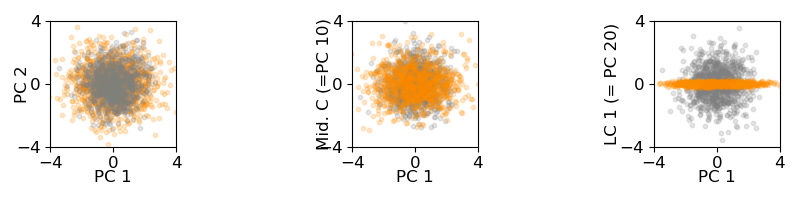

In [11]:
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
print(np.max(np.abs(PC12_projections_true)))
if dataset_name =='CR_batch':
    alpha = 0.2
    limval = 4
    special_head_length = 0.05*np.sqrt(true_eigvals[1]) #else it gets drawn in a weird manner.
elif 'Estrella' in dataset_name:
    alpha = 0.3
    limval = 5
    special_head_length = 0.5*np.sqrt(true_eigvals[1]) 
elif 'Soil' in dataset_name:
    alpha = 0.5
    limval = 21#8
    special_head_length = 0.5*np.sqrt(true_eigvals[1]) 
# alpha = 0.2 #0.5 for Soil, 0.3 for Estrela, 0.2 for CR_batch
''' Joint Figure with PC1 PC2, PCN/2 and PCN-1'''
mid_eigvect = np.shape(true_eigvects)[1]//2
print(mid_eigvect)
PCmid_projections_true = true_dataset @ true_eigvects[:,mid_eigvect]
PCmid_projections_null = null_dataset @ true_eigvects[:,mid_eigvect]

print('PC1 projection standard deviation',np.var(PC12_projections_true[:,1]),np.sqrt(true_eigvals[-1]))
print('Mid projection standard deviation',np.var(PCmid_projections_true),np.sqrt(true_eigvals[mid_eigvect]))
print('PClast projection standard deviation',np.var(PClast_projections_true[:,0]),np.sqrt(true_eigvals[low_eigvect]))

radius = 1 if M>N else np.sqrt(N/M)
# limval = 5 #7 for Estrella, 20 for soil, 5 for CR_batch. If using the same for all: 8 for Soil, 5.5 for Estrela; 5 for CR_batch
arrowidth = 0.75/15*limval
headwidth = 2*arrowidth
xlabelpad = -1
ylabelpad = -10

from matplotlib.patches import Circle
from matplotlib.patches import Wedge
plt.close('all')
fig,ax = plt.subplots(1,3,
                     # figsize=(5,2),
                      figsize = (8,2)
                     )
plt.subplots_adjust(
    wspace=-1)
''' PC1-PC2 projections '''
ax[0].scatter(PC12_projections_true[:,1],
           PC12_projections_true[:,0],
           alpha=alpha,
           color='darkorange',s=10,
           label='Data',zorder=1
          )
if plot_null_data:
    ax[0].scatter(PC12_projections_null[:,1],
               PC12_projections_null[:,0],
               alpha=alpha,
               color='gray',s=10,
               label='Null',zorder=2
              )
if add_arrows:
    ax[0].arrow(0,0,np.sqrt(true_eigvals[-1]),0,width=arrowidth,head_width=headwidth,head_length=0.3*np.sqrt(true_eigvals[-1]),
                edgecolor=[127/2/255,191/2/255,123/2/255],facecolor=[127/255,191/255,123/255],length_includes_head=True,zorder=10)
    ax[0].arrow(0,0,0,np.sqrt(true_eigvals[-2]),width=arrowidth,head_width=headwidth,head_length=0.3*np.sqrt(true_eigvals[-2]),
edgecolor=[127/2/255,191/2/255,123/2/255],facecolor=[127/255,191/255,123/255],length_includes_head=True,zorder=10)
ax[0].set_xlabel('PC 1',labelpad=xlabelpad)
ax[0].set_ylabel('PC 2',labelpad=ylabelpad)
patch = Circle((0,0),radius=radius, edgecolor='k',
               facecolor=(0, 0, 0, 0))
# ax[0].add_artist(patch) #Add Circle
# ring = Wedge(
#     center=(0, 0),
#     r=r_outer,
#     theta1=0,
#     theta2=360,
#     width=r_outer - r_inner,   # This creates the hole
#     facecolor='gray',
#     alpha=0.5,
# )
# ax[0].add_artist(ring)

ax[0].set_xticks([-limval,0,limval]); ax[0].set_yticks([-limval,0,limval])
ax[0].set_xlim((-limval,limval))
ax[0].set_ylim((-limval,limval))
ax[0].set_aspect('equal',anchor='W')
''' PC1-PCmid projections '''
arrowidth = 0.75/15*limval
headwidth = 2*arrowidth
xlabelpad = -1
ylabelpad = -10

ax[1].scatter(PC12_projections_true[:,1],
           PCmid_projections_true[:],
           alpha=alpha,
           color='darkorange',s=10,
           label='Data'
          )
if plot_null_data:
    ax[1].scatter(PC12_projections_null[:,1],
               PCmid_projections_null[:],
               alpha=alpha,
               color='gray',s=10,
               label='Null',zorder=0
              )
if add_arrows:
    ax[1].arrow(0,0,np.sqrt(true_eigvals[-1]),0,width=arrowidth,head_width=headwidth,head_length=0.3*np.sqrt(true_eigvals[-1]),
                edgecolor=[127/2/255,191/2/255,123/2/255],facecolor=[127/255,191/255,123/255],length_includes_head=True,zorder=10)
    ax[1].arrow(0,0,0,np.sqrt(true_eigvals[mid_eigvect]),width=arrowidth,head_width=headwidth,head_length=0.3*np.sqrt(true_eigvals[mid_eigvect]),
                edgecolor='dimgray',facecolor='lightgray',length_includes_head=True,zorder=10)
ax[1].set_xlabel('PC 1',labelpad=xlabelpad)
ax[1].set_ylabel('Mid. C (=PC {})'.format(min(N,M-1)-mid_eigvect),labelpad=ylabelpad)

ax[1].set_xticks([-limval,0,limval]); ax[1].set_yticks([-limval,0,limval])
ax[1].set_xlim((-limval,limval))
ax[1].set_ylim((-limval,limval))
patch = Circle((0,0),radius=radius, edgecolor='k',
               facecolor=(0, 0, 0, 0))
# ax[1].add_artist(patch) # Add Circle
if dataset_name =='Grilli.Soil':
    ''' Do an inset to zoom into the region with the circumference'''
    ax[1].set_ylim((-limval+2.5,limval+3))
    ## Create inset
    pos = [0.6,0.6,0.35,0.35]
    lims = (-3,3)
    head_length = 0.2*np.sqrt(true_eigvals[mid_eigvect])
    axins = ax[1].inset_axes(pos,
                          xlim=(lims),ylim=(lims),xticks=[],yticks=[],xticklabels=[],yticklabels=[])
    ## Plot same info as in main axes
    axins.scatter(PC12_projections_true[:,1],
           PCmid_projections_true[:],
           alpha=alpha,
           color='darkorange',s=10,)
    patch = Circle((0,0),radius=radius, edgecolor='k',
               facecolor=(0, 0, 0, 0))
    axins.add_artist(patch)
    # ring = Wedge(
    #         center=(0, 0),
    #         r=r_outer,
    #         theta1=0,
    #         theta2=360,
    #         width=r_outer - r_inner,   # This creates the hole
    #         facecolor='gray',
    #         alpha=0.5,
    #     )
    # axins.add_artist(ring)
    
    axins.arrow(0,0,0,np.sqrt(true_eigvals[mid_eigvect]),width=arrowidth,head_width=headwidth,
                head_length = head_length,
            edgecolor='dimgray',facecolor='lightgray',
            length_includes_head=True,zorder=10)
    #Indicate inset zoom
    ax[1].indicate_inset_zoom(axins,edgecolor='black')
# ring = Wedge(
#     center=(0, 0),
#     r=r_outer,
#     theta1=0,
#     theta2=360,
#     width=r_outer - r_inner,   # This creates the hole
#     facecolor='gray',
#     alpha=0.5,
# )
# ax[1].add_artist(ring)
ax[1].set_aspect('equal',anchor='C')

''' PC1-LC1 projections '''
arrowidth = 0.75/15*limval
headwidth = 2*arrowidth
xlabelpad = -1
ylabelpad = -10

ax[2].scatter(PC12_projections_true[:,1],
           PClast_projections_true[:,0],
           alpha=alpha,
           color='darkorange',s=10,
           label='Data'
          )
if plot_null_data:
    ax[2].scatter(PC12_projections_null[:,1],
               PClast_projections_null[:,0],
               alpha=alpha,
               color='gray',s=10,
               label='Null',zorder=0
              )
if add_arrows:
    ax[2].arrow(0,0,np.sqrt(true_eigvals[-1]),0,width=arrowidth,head_width=headwidth,head_length=0.3*np.sqrt(true_eigvals[-1]),
                edgecolor=[127/2/255,191/2/255,123/2/255],facecolor=[127/255,191/255,123/255],length_includes_head=True,zorder=10)
    ax[2].arrow(0,0,0,np.sqrt(true_eigvals[low_eigvect]),width=arrowidth,head_width=headwidth,head_length=special_head_length,
                edgecolor=[175/2/255,141/2/255,195/2/255],facecolor=[175/255,141/255,195/255],
                length_includes_head=True,zorder=10)
ax[2].set_xlabel('PC 1',labelpad=xlabelpad)
ax[2].set_ylabel('LC {} (= PC {})'.format(low_eigvect+1,min(N,M-1)-low_eigvect),labelpad=0)
ax[2].set_xticks([-limval,0,limval]); ax[2].set_yticks([-limval,0,limval])
ax[2].set_xlim((-limval,limval))
ax[2].set_ylim((-limval,limval))
patch = Circle((0,0),radius=radius, edgecolor='k',
               facecolor=(0, 0, 0, 0))
# ax[2].add_artist(patch) #Add circle
# ring = Wedge(
#     center=(0, 0),
#     r=r_outer,
#     theta1=0,
#     theta2=360,
#     width=r_outer - r_inner,   # This creates the hole
#     facecolor='gray',
#     alpha=0.5,
# )
# ax[2].add_artist(ring)
# if dataset_name=='CR_batch' or dataset_name =='Grilli.Soil':
if False:
    ''' Do an inset to zoom into the region with the circumference'''
    ax[2].set_ylim((-limval+2.5,limval+3))
    ## Create inset
    if 'CR' in dataset_name:
        pos =[0.35,0.35,0.6,0.6]
        lims = (-1.1,1.1)
        head_length = 0.05*np.sqrt(true_eigvals[1])
    elif 'Grilli' in dataset_name:
        pos = [0.6,0.6,0.35,0.35]
        lims = (-3,3)
        head_length = 0.5*np.sqrt(true_eigvals[0])
    axins = ax[2].inset_axes(pos,
                          xlim=(lims),ylim=(lims),xticks=[],yticks=[],xticklabels=[],yticklabels=[])
    ## Plot same info as in main axes
    axins.scatter(PC12_projections_true[:,1],
           PClast_projections_true[:,0],
           alpha=alpha,
           color='darkorange',s=10,)
    patch = Circle((0,0),radius=radius, edgecolor='k',
               facecolor=(0, 0, 0, 0))
    axins.add_artist(patch)
    # ring = Wedge(
    #         center=(0, 0),
    #         r=r_outer,
    #         theta1=0,
    #         theta2=360,
    #         width=r_outer - r_inner,   # This creates the hole
    #         facecolor='gray',
    #         alpha=0.5,
    #     )
    # axins.add_artist(ring)
    
    axins.arrow(0,0,0,np.sqrt(true_eigvals[low_eigvect]),width=arrowidth,head_width=headwidth,
                head_length = head_length,
            edgecolor=[175/2/255,141/2/255,195/2/255],facecolor=[175/255,141/255,195/255],
            length_includes_head=True,zorder=10)
    #Indicate inset zoom
    ax[2].indicate_inset_zoom(axins,edgecolor='black')
# ax[2].scatter(None,None,color='gray',label='Null')
# ax[2].legend(loc='best',frameon=True)
ax[2].set_aspect('equal',anchor='E')
plt.tight_layout()
format='svg'
plt.savefig('PC_projections.all.{}.{}'.format(dataset_name,format),transparent=True)